# Project 1

## Experimenting with Algorithms

In [9]:
# import numpy as np
# import skimage as sk
# import skimage.io as skio
# print("imports successful!")
# print(f"NumPy version: {np.__version__}")
# print(f"Scikit-image version: {sk.__version__}")

In [22]:
# CS180 (CS280A): Project 1 starter Python code

# these are just some suggested libraries
# instead of scikit-image you could use matplotlib and opencv to read, write, and display images

import numpy as np
import skimage as sk
import skimage.io as skio

import os # added so i can turn the image data folder into a list to loop over

# name of the input file
imname = 'cs180 proj1 data/cathedral.jpg'

# read in the image
im = skio.imread(imname)

# convert to double (might want to do this later on to save memory)    
im = sk.img_as_float(im)
    
# compute the height of each part (just 1/3 of total)
height = np.floor(im.shape[0] / 3.0).astype(int)

# separate color channels
b = im[:height]
g = im[height: 2*height]
r = im[2*height: 3*height]

In [23]:
# how we calculate our image matching score
def l2_norm(img1, img2): # trying the basic loss metric 
    return np.sqrt(np.sum((img1 - img2) ** 2)) # formula given in project spec

def align(img, ref, shift = 15): # reference = anchor image, we shift to match with the ref
    best_score = float('inf') # score to find the best displacement
    best_shift = (0, 0) # we start with no shift
    aligned = img # first set to og image
    
    for dy in range(-shift, shift + 1):
        for dx in range(-shift, shift + 1):
            shifted = np.roll(img, shift = (dy, dx), axis = (0, 1))
            score = l2_norm(ref, shifted) # using our loss function
            if score < best_score:
                best_score = score
                best_shift = (dy, dx)
                aligned = shifted

    print(f"Best shift: {best_shift}")
    return aligned

In [27]:
# need to speed up, try image pyramid
def align_pyramid(img, ref, max_shift = 15, levels = 4):
    # using fixed parameters as per spec with value 15 pixels here, maybe change 
    
    pyramid_img = [img] # initialize to original image, full-size
    pyramid_ref = [ref]
    
    for i in range(1, levels):
        # downscale
        # take previous pyramid image and scale down 50%, then append to list
        img_rescaled =sk.transform.rescale(pyramid_img[i - 1], 0.5, anti_aliasing = True)
        pyramid_img.append(img_rescaled)
        ref_rescaled = sk.transform.rescale(pyramid_ref[i - 1], 0.5, anti_aliasing = True)
        pyramid_ref.append(ref_rescaled)
    
    shift = (0, 0) # initial shift

    for level in reversed(range(levels)): # start from smallest image level 3 -> 0
        img_level = pyramid_img[level] # index into the right level
        ref_level = pyramid_ref[level]

        best_score = float('inf') # score to find the best displacement
        best_shift = (0, 0) # we start with no shift

        # double shift from previous pyramid level to estimate for current level
        # range is with +- max_shift
        for dy in range(shift[0] * 2 - max_shift, shift[0] * 2 + max_shift + 1):
            for dx in range(shift[1]*2 - max_shift, shift[1] * 2 + max_shift + 1):
                shifted = np.roll(img_level, shift = (dy, dx), axis = (0, 1))
                # cropping borders to see if we can get better alignment
                h, w = ref_level.shape
                margin = int(0.1 * min(h, w))
                # compute score only on cropped region
                score = l2_norm(ref_level[margin: -margin, margin: -margin], shifted[margin: -margin, margin: -margin])
                if score < best_score:
                    best_score = score
                    best_shift = (dy, dx)

        shift = best_shift # update shift for this level

    print(f"Final best shift: {shift}")
    return np.roll(img, shift = shift, axis = (0, 1))

In [13]:
# # align the images
# # functions that might be useful for aligning the images include:
# # np.roll, np.sum, sk.transform.rescale (for multiscale)

# # iterative alignment
# # ag = align(g, b)
# # ar = align(r, b)

# # trying image pyramid speed up
# ag = align_pyramid(g, b)
# ar = align_pyramid(r, b)

# # create a color image
# im_out = np.dstack([ar, ag, b])
# im_out_uint8 = sk.img_as_ubyte(im_out) # convert to uint8 for skio.imsave to work

# # save the image
# fname = 'output/aligned_cathedral.jpg'
# skio.imsave(fname, im_out_uint8)

# # display the image
# skio.imshow(im_out)
# skio.show()

## Testing Algorithm on Larger Image(s)

In [14]:
# # name of the input file
# imname = 'cs180 proj1 data/church.tif'

# # read in the image
# im = skio.imread(imname)

# # convert to double (might want to do this later on to save memory)    
# im = sk.img_as_float(im)
    
# # compute the height of each part (just 1/3 of total)
# height = np.floor(im.shape[0] / 3.0).astype(int)

# # separate color channels
# b = im[:height]
# g = im[height: 2*height]
# r = im[2*height: 3*height]

# # align the images
# # functions that might be useful for aligning the images include:
# # np.roll, np.sum, sk.transform.rescale (for multiscale)

# # iterative alignment
# # ag = align(g, b)
# # ar = align(r, b)

# # trying image pyramid speed up
# ag = align_pyramid(g, b)
# ar = align_pyramid(r, b)

# # create a color image
# im_out = np.dstack([ar, ag, b])
# im_out_uint8 = sk.img_as_ubyte(im_out) # convert to uint8 for skio.imsave to work

# # save the image
# fname = 'output/church.jpg' # converting images to jpg to save disk space as per spec
# skio.imsave(fname, im_out_uint8)

# # display the image
# skio.imshow(im_out)
# skio.show()

## Try Calling on All Photos

In [27]:
def color(imname, fname):
    # following starter code format
    # read image
    im = skio.imread(imname)
    im = sk.img_as_float(im)

    # split into three channels
    height = np.floor(im.shape[0] / 3.0).astype(int)

    # based on the images, the shots are lined up vertically so we separate on height
    b = im[:height]
    g = im[height:2*height]
    r = im[2*height:3*height]

    # align using pyramid strategy
    ag = align_pyramid(g, b, 15, 4) # fix parameters where shift = 15, levels = 4
    ar = align_pyramid(r, b, 15, 4)

    # combine
    im_out = np.dstack([ar, ag, b])
    im_out_uint8 = sk.img_as_ubyte(im_out)

    # image naming convention = output/aligned + original filename + .jpg
    base, x = os.path.splitext(fname)
    outname = f"aligned_{base}.jpg"
    outpath = os.path.join("output", outname)

    # save
    skio.imsave(outpath, im_out_uint8)
    print(f"Saved aligned image as {outpath}")

    # display image
    skio.imshow(im_out)
    skio.show()
    

Final best shift: (49, 24)
Final best shift: (103, 57)
Saved aligned image as output/aligned_emir.jpg


/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_68200/552357437.py:31: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_out)
/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_68200/552357437.py:32: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


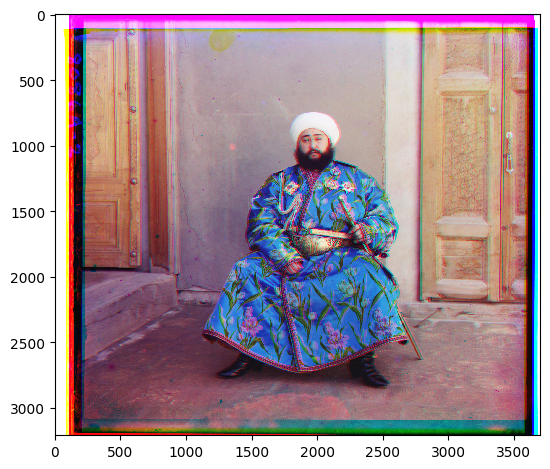

In [ ]:
# try calling on each photo in data folder
for fname in os.listdir("cs180 proj1 data"):
    if fname.lower().endswith((".tif", ".jpg", ".png")): # not sure why colorize_skel.py file is here also? only want image file types
        # ohh bruh jk mb it's the skeleton code, was also given in spec
        inpath = os.path.join("cs180 proj1 data", fname)
        color(inpath, fname)

Final best shift: (76, -3)
Final best shift: (161, -20)
Saved aligned image as output/aligned_students.jpg


/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_68200/3790814677.py:33: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_out)
/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_68200/3790814677.py:34: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


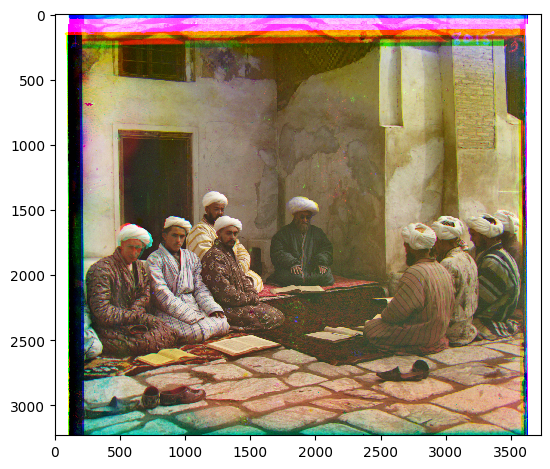

Final best shift: (16, 1)
Final best shift: (104, -1)
Saved aligned image as output/aligned_tipy_dagestana.jpg


/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_68200/3790814677.py:33: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_out)
/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_68200/3790814677.py:34: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


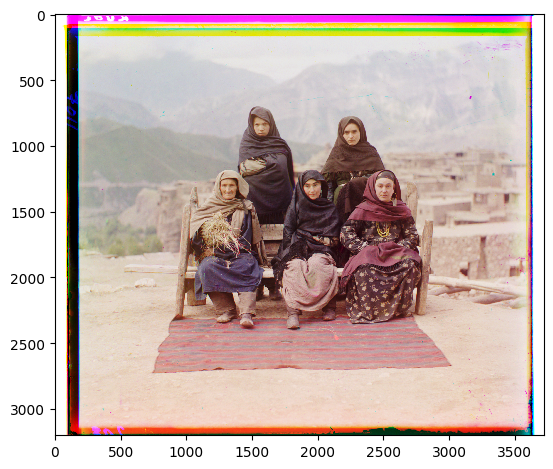

Final best shift: (-16, 10)
Final best shift: (11, 17)
Saved aligned image as output/aligned_peasant_girls.jpg


/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_68200/3790814677.py:33: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_out)
/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_68200/3790814677.py:34: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


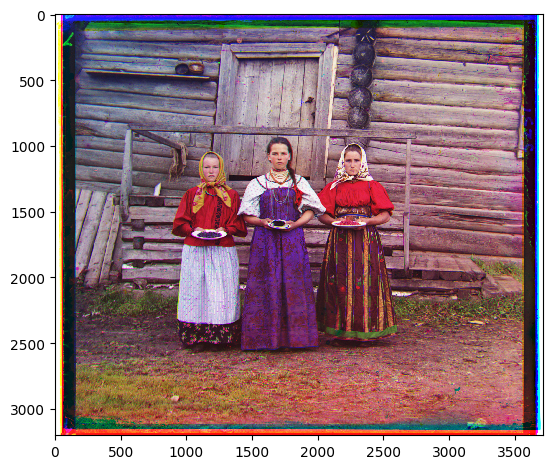

In [29]:
# call on additional photos from the Prokudin-Gorskii collection 

for fname in os.listdir("more_photos"):
    if fname.lower().endswith((".tif", ".jpg", ".png")): # not sure why colorize_skel.py file is here also? only want image file types
        # ohh bruh jk mb it's the skeleton code, was also given in spec
        inpath = os.path.join("more_photos", fname)
        color(inpath, fname)